## projects

Here are some examples of quick projects.

The examples in this notebook do some of the ETL (Extract, Transform, Load) work. Copy and modify my code if you want to. It's open-source!

These examples all use datasets from the repo.
If you want to use datasets from other sources, that's OK.


In [1]:
from pathlib import Path
import pandas as pd

In [2]:
# You might need to change this.
DATA = Path.cwd() / "data"
print(f"The data folder is here: {DATA}")

The data folder is here: /Users/void/code/chengdu/science/data


In [3]:
def clean_cols(data):
    # Convert column names to lowercase without whitespace.
    return [x.lower().replace(' ', '_').strip() for x in data.columns]

## city names

Project ideas:
- How many of the cities in this table are in China?
- What are all the `subcountry` values for those cities?
- Answer the same questions about another country.

In [4]:
# Read raw data and choose an index column.
cities = pd.read_csv(DATA / "cities.csv")
cities.columns = clean_cols(cities)
cities = cities.set_index('geonameid').sort_index()

# Show data types and null counts
print("Data types:")
print(cities.dtypes)
print("Null counts:")
print(cities.isnull().sum())

cities

Data types:
name          str
country       str
subcountry    str
dtype: object
Null counts:
name            0
country         0
subcountry    123
dtype: int64


,name,country,subcountry
geonameid,,,
490,Lavāsān,"Iran, Islamic Republic of",Tehran
10570,Alvand,"Iran, Islamic Republic of",Qazvin Province
11725,Zīr Āb,"Iran, Islamic Republic of",Mazandaran
14256,Āzādshahr,"Iran, Islamic Republic of",Hamadan Province
18918,Protaras,Cyprus,Ammochostos
...,...,...,...
13607975,Polo Nord,Italy,Piedmont
13607979,Centro,Italy,Piedmont
13608000,Jinshan,China,Shanghai


In [5]:
# Select cities in a specific country.
cities.loc[cities['country'] == 'China']

,name,country,subcountry
geonameid,,,
1279471,Zhefang,China,Yunnan
1279485,Zhangfeng,China,Yunnan
1279501,Zepu,China,Xinjiang
1279553,Zibihu,China,Yunnan
1279575,Yingpan,China,Yunnan
...,...,...,...
13561750,Huyanghe,China,Xinjiang
13561768,Tianducheng,China,Zhejiang
13608000,Jinshan,China,Shanghai


<Axes: xlabel='country', ylabel='# of cities in table'>

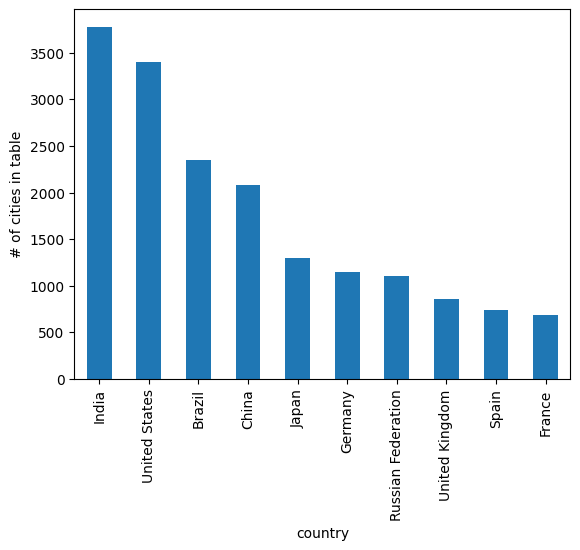

In [6]:
# Example project: Which countries have the most cities?
(
    cities
    .groupby('country')
    .count()['name']
    .nlargest(10)
    .plot(
        kind='bar',
        ylabel="# of cities in table",
    )
)

## top-level internet domains

In [7]:
domains = pd.read_csv(DATA / "domains.csv")
domains.columns = clean_cols(domains)
domains = domains.set_index('domain').sort_index()

# Show data types and null counts
print("Data types:")
print(cities.dtypes)
print("Null counts:")
print(cities.isnull().sum())

domains

Data types:
name          str
country       str
subcountry    str
dtype: object
Null counts:
name            0
country         0
subcountry    123
dtype: int64


,type,sponsoring_organization
domain,,
.aaa,generic,"American Automobile Association, Inc."
.aarp,generic,AARP
.abarth,generic,Not assigned
.abb,generic,ABB Ltd
.abbott,generic,"Abbott Laboratories, Inc."
...,...,...
‏.موريتانيا‎,country-code,Université de Nouakchott Al Aasriya
‏.موقع‎,generic,Helium TLDs Ltd
‏.همراه‎,generic,Emergency Back-End Registry Operator Program -...


In [8]:
# Show all domain types
for x in sorted(set(domains['type'])):
    print(x)

country-code
generic
generic-restricted
infrastructure
sponsored
test


In [9]:
# Example project: Find all country codes that start with 'u'
is_country = domains['type'] == 'country-code'
u_first = domains.index.str.startswith('.u')
domains.loc[is_country & u_first]


,type,sponsoring_organization
domain,,
.ua,country-code,Hostmaster Ltd.
.ug,country-code,Uganda Online Ltd.
.uk,country-code,Nominet UK
.um,country-code,Not assigned
.us,country-code,"Registry Services, LLC"
.uy,country-code,SeCIU - Universidad de la Republica
.uz,country-code,Single Integrator for Creation and Support of ...
